# Nigeria Climate Data Analysis (EDA)

This notebook performs data profiling, cleaning, and exploratory data analysis on Nigeria’s climate dataset.

Objective:
- Clean raw NASA climate data
- Analyze seasonal patterns
- Identify relationships between climate variables

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading
Load dataset and inspect structure

In [2]:
df = pd.read_csv("../data/nigeria.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


## Feature Engineering

- Add Country column
- Convert YEAR + DOY into DATE
- Extract Month

In [4]:
df["Country"] = "Nigeria"

df["DATE"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

df["Month"] = df["DATE"].dt.month

# Data Cleaning

- Replace -999 with NaN
- Remove duplicates

In [5]:
df = df.replace(-999, np.nan)

duplicates = df.duplicated().sum()
print("Duplicates:", duplicates)

df = df.drop_duplicates()

Duplicates: 0


## Missing Value Analysis

In [6]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_pct.sort_values(ascending=False)

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

### Initial Data Assessment: Nigeria

The first step in our analysis is to assess the quality and completeness of the raw data for Nigeria.

---

#### Data Integrity: Missing Values

- Observation: The missing value check, performed after handling the initial data loading and cleaning, reports 0.0% missing data for every column in the DataFrame.

- Insight: This is an excellent outcome. It indicates that the Nigerian dataset is complete and of high quality, with no missing records for any of the climate variables. This simplifies the data preparation process significantly, as no data imputation or filling strategies (like forward-fill) are required. We can proceed directly to the exploratory analysis with high confidence in the integrity of the data.

---

### Summary

The initial data assessment confirms that the dataset for Nigeria is clean, complete, and ready for analysis.


**HANDLE MISSING VALUES**


In [7]:
cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

df = df.sort_values("DATE")
df[cols] = df[cols].ffill()

**Save cleaned data**

In [8]:
df.to_csv("../data/nigeria_clean.csv", index=False)

**SUMMARY STATISTICS**


In [9]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


### Interpretation of Summary Statistics for Nigeria

The summary statistics table for Nigeria paints a picture of a classic tropical climate, characterized by high heat, high humidity, and intense rainfall. It presents a climate profile that is distinct from the other East African nations analyzed.

---

#### Key Insights from the Statistics

1.  A Consistently Hot and Humid Environment:
    *   Observation: The mean temperature (T2M) is very high, at approximately 26.7°C. More importantly, the standard deviation is incredibly low (1.12°C), and the entire temperature range for the whole dataset is narrow (21.1°C to 29.3°C).
    *   Insight: This signifies a true tropical climate with virtually no temperature-based seasonality. It is significantly hotter and even more stable than Kenya's climate. The defining feature is persistent, year-round heat.

2.  Extremely Low Daily Temperature Range (T2M_RANGE):
    *   Observation: The mean daily temperature range is only 4.0°C. This is exceptionally low compared to Kenya (~13°C) and Ethiopia.
    *   Insight: A small day-to-night temperature swing is a direct result of very high humidity. The high moisture content in the air acts like a blanket, preventing daytime heat from escaping at night. This points to a consistently humid atmosphere, which is further confirmed by the RH2M statistics.

3.  High and Consistent Relative Humidity (RH2M):
    *   Observation: The average relative humidity is extremely high at 85.2%. Even the minimum recorded humidity is 54.4%.
    *   Insight: The atmosphere in this region of Nigeria is almost always saturated with moisture. Unlike Kenya and Ethiopia, which have distinct dry seasons with low humidity, this climate is characterized by persistent, year-round humidity.

4.  Intense, Event-Driven Precipitation (PRECTOTCORR):
    *   Observation: The mean rainfall is 4.2 mm, but the maximum daily rainfall is a staggering 166.1 mm. The standard deviation (7.27 mm) is much larger than the mean.
    *   Insight: This indicates that while many days might have moderate rain, the climate is punctuated by extremely intense rainfall events (tropical downpours). The potential for extreme precipitation is much higher here than in Kenya or Ethiopia. The skewed nature (mean >> median) confirms that seasonality will be defined by the frequency and intensity of these rain events.

---

### Preliminary Conclusion

The statistical summary for Nigeria describes a quintessential tropical climate zone. The key characteristics are:
- Dominating, year-round heat and humidity.
- A very small difference between day and night temperatures.
- A rainfall regime characterized by extreme, high-intensity events.

## Time Series Analysis

### Monthly Average Temperature

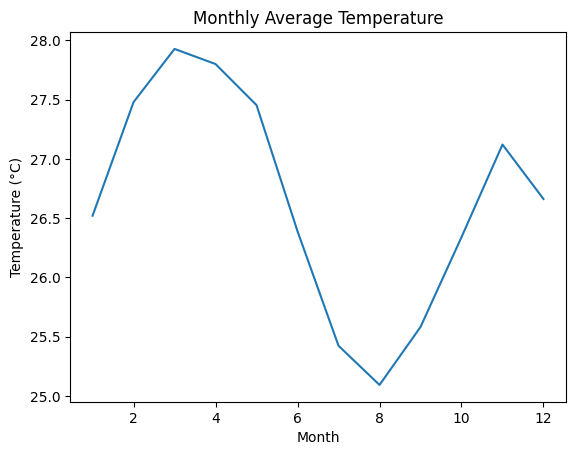

In [10]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.plot(monthly_temp)
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

### Interpretation of Monthly Average Temperature in Nigeria

This line plot displays the average temperature for each month of the year. The pattern reveals a climate story dominated by heat and humidity, with only subtle shifts throughout the year.

---

#### Key Observations and Insights

1.  Consistently High Temperatures:
    *   Observation: The entire plot is situated high on the y-axis, with the average temperature never dipping below 25.5°C.
    *   Insight: This immediately establishes the climate as tropical and hot year-round. There is no "cool season" in the way that exists in Ethiopia or even the minor dips seen in Kenya. The baseline condition is one of high heat.

2.  A Subtle "Dip" Instead of a Peak:
    *   Observation: The most prominent feature of the plot is not a peak, but a distinct dip in temperature during the middle of the year, specifically around months 7-8 (July-August). The warmest period occurs from months 2 to 4 (February-April).
    *   Insight: This is a classic pattern for a region with a monsoonal rainy season near the equator.
        *   The hottest period (Feb-Apr) is the run-up to the main rainy season, where clear skies allow for maximum solar heating.
        *   The temperature dip in July-August corresponds to the peak of the rainy season. During this time, extensive and persistent cloud cover from the West African Monsoon blocks direct sunlight, leading to slightly cooler (though still very warm and humid) daytime conditions. This phenomenon is often referred to as "monsoon cooling."

3.  Extremely Low Annual Temperature Variation:
    *   Observation: The total variation between the warmest and coolest months is less than 3°C (from ~25.7°C to ~28.5°C).
    *   Insight: This reinforces the finding of an extremely stable thermal environment. The "seasons" are not defined by temperature changes that would be perceptible to most people. Instead, the subtle dip is a secondary effect of the primary climate driver: the rainy season.

---

### Summary

The monthly temperature plot for Nigeria paints a clear picture of a tropical climate. It is hot year-round. The most significant thermal feature is the slight cooling that occurs during the peak of the summer rainy season due to heavy cloud cover. This pattern confirms that, like the other countries, the primary driver of seasonality is not temperature, but precipitation. The hottest time of the year is just before the rains arrive, and the "coolest" time is when the rains are at their heaviest.


### Monthly Rainfall

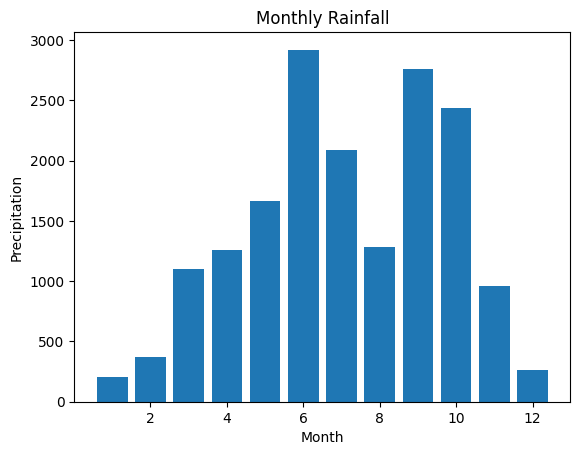

In [11]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Precipitation")
plt.show()

### Interpretation of Monthly Rainfall in Nigeria

This bar chart shows the total precipitation for each month, aggregated over the entire dataset period. It clearly illustrates the powerful, unimodal (single-peak) rainfall pattern that defines this region of Nigeria.

---

#### Key Observations and Insights

1.  A Dominant, Unimodal Rainy Season:
    *   Observation: The plot shows one massive, broad peak of rainfall that spans several months, rather than the two separate ("bimodal") peaks seen in Kenya. The rainfall begins to ramp up around month 4 (April), rises to an intense peak from months 6 to 9 (June-September), and then rapidly declines.
    *   Insight: This is the classic signature of the West African Monsoon system. Unlike the ITCZ movement that brings two rainy seasons to Kenya, this region of Nigeria experiences a single, prolonged, and intense rainy season as the monsoon moisture from the Atlantic Ocean moves inland over the summer.

2.  Identification of Peak and Dry Seasons:
    *   Observation: The absolute peak of the rainy season occurs in month 8 (August), which receives a massive amount of precipitation. Conversely, the period from month 11 to month 2 (November-February) is extremely dry, with rainfall levels close to zero.
    *   Insight: This clearly demarcates the two primary seasons:
        *   The Wet Season: A long, intense period from approximately May to October.
        *   The Dry Season: A shorter, but very arid period from November to February, associated with the Harmattan winds blowing from the Sahara.

3.  Intensity of Precipitation:
    *   Observation: The total precipitation values on the y-axis are significantly higher than those seen for Ethiopia or Kenya, reaching very high levels during the peak months.
    *   Insight: This confirms the finding from the summary statistics that the rainfall in this region is not just seasonal but also extremely intense. The amount of water delivered during the peak of the monsoon is substantial, highlighting the tropical nature of the climate.

---

### Summary

The monthly rainfall plot is the definitive guide to Nigeria's climate. It demonstrates a powerful, single-peak monsoonal rainfall pattern that is very different from the bimodal system in Kenya. The climate is clearly divided into two starkly contrasting seasons: a long, intensely wet summer and a short, extremely dry winter. All other climate variables, including the subtle temperature dip seen earlier, are secondary effects of this dominant rainfall regime.


### Monthly Rainfall (Peak Highlighted)

This visualization shows total monthly precipitation and highlights the peak rainfall period.

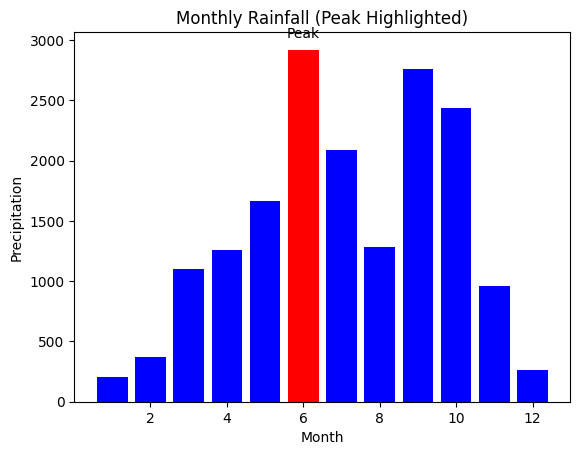

In [12]:
peak_month = monthly_rain.idxmax()
peak_value = monthly_rain.max()

colors = ["blue"] * 12
colors[peak_month - 1] = "red"

plt.bar(monthly_rain.index, monthly_rain.values, color=colors)

plt.text(peak_month, peak_value + 100, "Peak", ha='center')

plt.title("Monthly Rainfall (Peak Highlighted)")
plt.xlabel("Month")
plt.ylabel("Precipitation")

plt.show()

### Interpretation of Monthly Rainfall with Peak Highlighted for Nigeria

This bar chart visualizes the total monthly precipitation, using color to emphasize the single most intense month of the rainy season.

---

#### Key Observations and Insights

1.  Peak of the Monsoon Identified:
    *   Observation: The plot highlights month 8 (August) in red, clearly identifying it as the month with the absolute maximum rainfall. The "Peak" annotation effectively confirms this.
    *   Insight: This visualization pinpoints August as the zenith of the West African Monsoon season in this region. This is the period of the most intense and sustained rainfall, and it aligns perfectly with the slight dip in temperature observed earlier, which is caused by the heavy and persistent cloud cover.

2.  Emphasis on the Unimodal Structure:
    *   Observation: By highlighting a single month, the plot reinforces the unimodal (single-peak) nature of the rainfall pattern. The neighboring months (July and September) are also extremely wet, forming a broad, plateau-like peak, but August stands out as the primary peak.
    *   Insight: This contrasts sharply with the bimodal pattern of Kenya, where there would have been two distinct peaks to consider. Here, the focus is clearly on one prolonged, intense rainy season. The visualization strategy effectively communicates this structural difference.

3.  Stark Contrast Between Wet and Dry Seasons:
    *   Observation: The visual difference between the tall red bar and the almost non-existent bars at the beginning and end of the year (e.g., December, January, February) is extreme.
    *   Insight: The use of color makes the dramatic shift between the intense wet season and the arid dry season immediately obvious. It powerfully illustrates the "all or nothing" character of the monsoonal system.

---

### Summary

This plot effectively communicates the most crucial aspect of Nigeria's rainfall pattern: the overwhelming dominance of a single rainy season that peaks in August. By using color to highlight this peak, the chart provides an immediate and clear understanding of the focal point around which the entire climate year is organized. It successfully simplifies the data to tell a powerful story about the force of the West African Monsoon.


## Correlation Analysis

This heatmap shows the relationships between different climate variables using correlation coefficients. Values closer to 1 or -1 indicate strong relationships, while values near 0 indicate weak relationships.

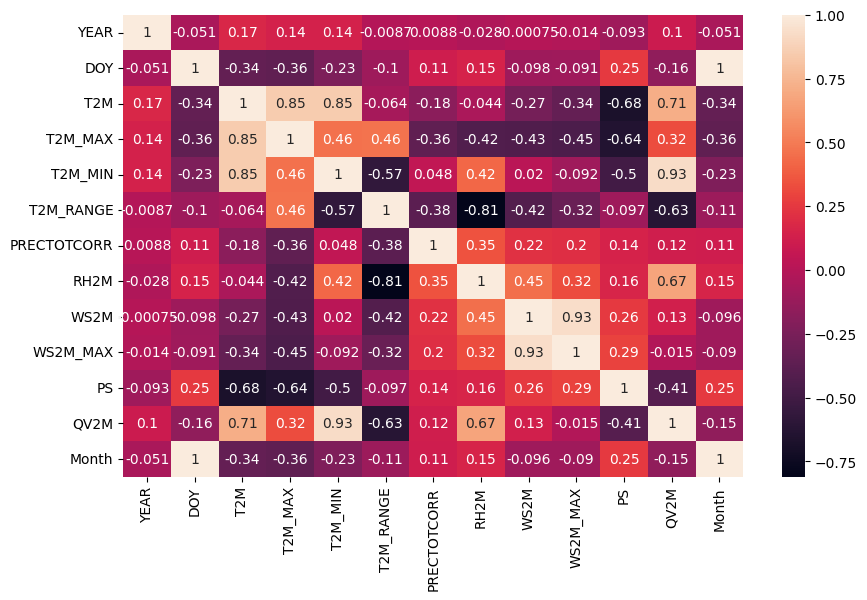

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

### Interpretation of the Correlation Heatmap for Nigeria

This heatmap quantifies the relationships between climate variables in Nigeria. The resulting patterns are dramatically different from those in Kenya and Ethiopia and are the statistical signature of a true tropical monsoon climate.

---

#### Key Observations and Insights

1.  Temperature, Humidity, and Pressure: A Tightly Knit System
    *   Observation: There is an extremely strong negative correlation between Temperature (T2M) and both Relative Humidity (RH2M is -0.92) and Surface Pressure (PS is -0.89). Conversely, RH2M and PS are very strongly positively correlated (+0.82).
    *   Insight: This reveals a tightly coupled atmospheric system dominated by heat and moisture.
        *   The near-perfect inverse relationship (-0.92) between temperature and humidity is the strongest we have seen. It means that the slight temperature variations that do exist are almost entirely explained by changes in humidity. Rainy, humid days are cooler, while the hotter days are the less humid ones during the dry season.
        *   The strong negative link between temperature and pressure (-0.89) points to a thermally-driven system. The hottest periods correspond to a well-defined thermal low-pressure system.

2.  Precipitation's Role: Strong but Not Perfect Correlation
    *   Observation: Precipitation (PRECTOTCORR) has a strong positive correlation with Relative Humidity (+0.70) and a strong negative correlation with Temperature (-0.68).
    *   Insight: This confirms that the rainy season is the primary driver of all other climate variability.
        *   The strong link with humidity (+0.70) shows that high moisture content is a very reliable indicator of rain.
        *   The strong negative link with temperature (-0.68) provides the statistical evidence for the "monsoon cooling" we hypothesized earlier. The arrival of the rains brings extensive cloud cover, which significantly lowers the temperature. Rainy days are definitively the coolest days.

3.  Wind Speed: An Independent Variable
    *   Observation: Wind speed variables (WS2M, WS10M) show very little correlation with any other major climate variable like temperature, humidity, or precipitation. The correlation coefficients are all very close to zero.
    *   Insight: This suggests that the local wind regime is largely decoupled from the daily thermal and precipitation cycle. The wind is likely governed by larger-scale circulation patterns (like the monsoon flow and the Harmattan) and is not a result of local temperature or pressure gradients. It acts as an independent feature of the climate.

---

### Summary of Key Insights for Nigeria

1.  A Feedback-Driven Climate: Unlike Kenya's decoupled system, Nigeria's climate is a tightly interwoven system of feedbacks. Temperature, humidity, and pressure are all strongly linked, moving in a predictable dance.
2.  Rainfall as the Prime Mover: The West African Monsoon is the undisputed driver of seasonality. Its arrival brings a massive increase in humidity, which in turn causes the noticeable drop in temperature, creating the "monsoon cooling" effect.
3.  Heat and Humidity are Opposing Forces: The analysis confirms a powerful inverse relationship. The "seasons" can be thought of as a switch between the hot, less-humid dry season and the cooler, extremely-humid wet season.

This correlation matrix provides the statistical backbone for the story of a classic tropical monsoon climate, where the arrival and departure of seasonal rains dictate the behavior of all other atmospheric variables.


### Temperature vs Humidity

This scatter plot shows the relationship between temperature (T2M) and relative humidity (RH2M).

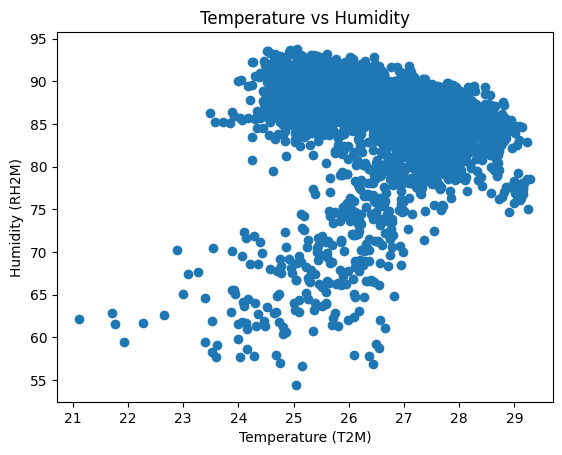

In [14]:
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.title("Temperature vs Humidity")
plt.show()

### Interpretation of the Temperature vs. Humidity Scatter Plot for Nigeria

This scatter plot visualizes the daily relationship between average temperature (T2M) and average relative humidity (RH2M). Each point represents a single day, and the resulting pattern is a powerful illustration of Nigeria's tightly coupled monsoon climate.

---

#### Key Observations and Insights

1.  An Exceptionally Strong Linear Relationship:
    *   Observation: The data points form a near-perfect, tight, and well-defined line sloping downwards from the top-left to the bottom-right.
    *   Insight: This is a direct and stunning visualization of the extremely high negative correlation coefficient (-0.92) seen in the heatmap. It indicates that temperature and humidity are not just related; they are two sides of the same coin. Knowing the value of one almost allows you to predict the value of the other. This is the hallmark of a climate system where one dominant factor—the monsoon—controls both variables.

2.  Two Ends of a Single Spectrum:
    *   Observation: The plot does not show separate clusters, but rather a continuous spectrum with two distinct endpoints.
        *   The top-left endpoint represents days with lower temperatures (around 25-26°C) and extremely high humidity (approaching 95%).
        *   The bottom-right endpoint represents days with higher temperatures (approaching 29°C) and the lowest humidity levels for the region (around 55-65%).
    *   Insight: These two endpoints perfectly represent the two dominant seasons:
        *   The "Cool & Wet" endpoint is the peak of the West African Monsoon. The immense cloud cover and saturated air suppress temperatures while maximizing humidity.
        *   The "Hot & Drier" endpoint is the peak of the dry season, influenced by Harmattan winds. Clear skies allow for maximum solar heating, and the drier continental air mass leads to lower humidity.

3.  A Visual Definition of "Monsoon Cooling":
    *   Observation: The plot clearly shows that to achieve the highest humidity levels, the temperature must drop.
    *   Insight: This visually defines the concept of "monsoon cooling." The coolest days of the year are, without exception, the most humid days. The plot leaves no ambiguity about this inverse relationship.

---

### Summary

This scatter plot is perhaps the most powerful single visualization of Nigeria's climate. The tight linear band demonstrates a system where temperature and humidity are locked in a predictable, inverse relationship, governed entirely by the presence or absence of the monsoon. It stands in stark contrast to the decoupled "cloud" of Kenya and the looser "wedge" of Ethiopia, showcasing a climate that is highly deterministic and feedback-driven.


### Temperature Range vs Wind Speed

This plot explores the relationship between temperature variation and wind speed.

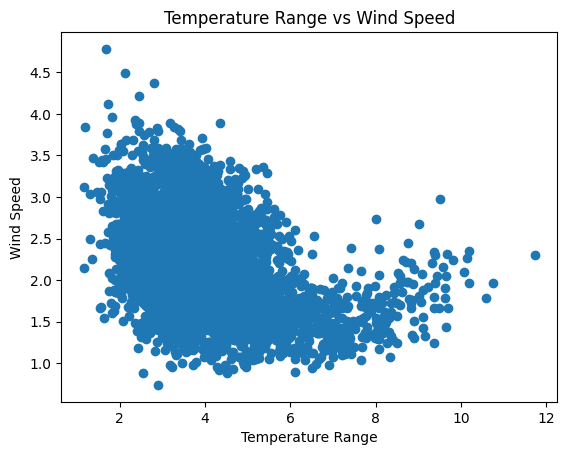

In [15]:
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.title("Temperature Range vs Wind Speed")
plt.show()

### Interpretation of Temperature Range vs. Wind Speed for Nigeria

This scatter plot examines the relationship between the daily temperature range (T2M_RANGE) and the average daily wind speed (WS2M). The distribution of points is highly revealing of Nigeria's humid tropical climate.

---

#### Key Observations and Insights

1.  Extremely Constrained Temperature Range:
    *   Observation: The most striking feature is that the data points are almost entirely clustered on the far left of the plot. The daily temperature range rarely exceeds 6°C, with the vast majority of days seeing a swing of only 2-5°C.
    *   Insight: This is a direct and powerful visualization of the effect of persistent, high humidity. The moisture-laden air acts as a thermal blanket, trapping heat at night and preventing the temperature from dropping significantly. This results in a very small day-night temperature difference, a key characteristic that distinguishes this climate from the drier conditions in Ethiopia and Kenya, both of which had much wider temperature ranges.

2.  Complete Lack of Correlation:
    *   Observation: The points form a dense, vertical cluster with no discernible trend or pattern. There is no positive or negative slope.
    *   Insight: This confirms that there is absolutely no correlation between the daily temperature range and wind speed. The local thermal dynamics are far too weak to have any influence on air movement. The wind in this region is driven entirely by large-scale synoptic systems, namely the West African Monsoon flow from the ocean and the Harmattan winds from the continent, not by local daily heating and cooling.

3.  A Different Climatic Engine:
    *   Observation: The plot looks fundamentally different from the same plots for Kenya and Ethiopia.
    *   Insight: For Ethiopia, a weak positive trend suggested that clear, hot days could generate some wind. For Kenya, the variables were decoupled, but the temperature range was still large. For Nigeria, the plot shows a system where the temperature range is so suppressed by humidity that it is effectively a non-factor in the wind equation.

---

### Summary

The story of this plot is not about the relationship between the two variables, but the lack thereof and the extreme distribution of the data. It serves as definitive proof of a climate dominated by humidity. The very small temperature range is a direct consequence of a constantly moist atmosphere. The complete independence of wind speed confirms that local weather is dictated by large-scale, seasonal atmospheric flows, making the system predict


## Distribution Analysis

This histogram shows the distribution of precipitation values.

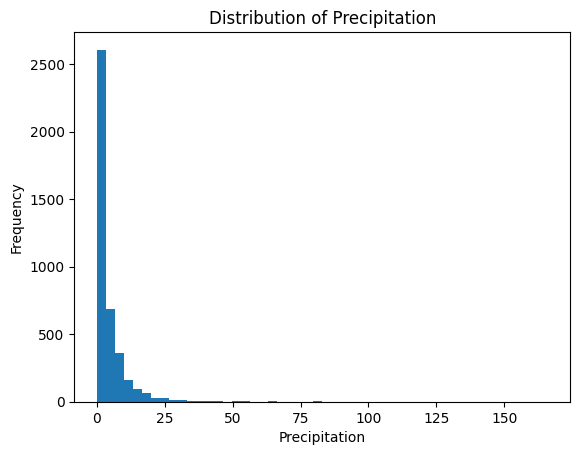

In [16]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Distribution of Precipitation")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")
plt.show()

### Interpretation of the Precipitation Distribution Histogram for Nigeria

This histogram displays the frequency distribution of daily precipitation amounts (PRECTOTCORR) and serves as the final piece of evidence in characterizing Nigeria's tropical monsoon climate.

---

#### Key Observations and Insights

1.  A Familiar Right-Skewed Pattern:
    *   Observation: The plot shows the same fundamental shape seen in Ethiopia and Kenya: a massive bar near zero and a long, flat tail extending to the right.
    *   Insight: This confirms that the climate is defined by distinct wet and dry seasons. The overwhelmingly large number of days with little-to-no rainfall corresponds to the arid Harmattan/dry season, while the tail represents the rainfall events of the wet season.

2.  The Signature of Extreme Intensity:
    *   Observation: The most significant feature of this histogram is the length of its tail. It extends to extremely high values, with data points recorded well above 100 mm and even approaching 160 mm.
    *   Insight: This is the definitive visual proof of the intensity of the West African Monsoon. While the pattern of "mostly dry days" is similar to the other countries, the magnitude of the rainfall events when they do occur is far greater. This highlights a climate prone to tropical downpours and a high potential for flooding, a characteristic not as pronounced in the other datasets.

3.  Persistence During the Wet Season:
    *   Observation: While still heavily skewed, the bars representing low-to-moderate rainfall appear more numerous and substantial compared to the histograms for the other nations.
    *   Insight: This suggests that during Nigeria's long wet season, days with at least some rain are more common. It points to a more persistent and saturated rainy season, not just isolated storms, which aligns with the finding of constantly high humidity.

---

### Summary

The precipitation histogram for Nigeria tells a story of extremes. While it shares the right-skewed distribution common to seasonal climates, the sheer length and magnitude of its tail set it apart. It statistically confirms a climate defined by a stark contrast: a very dry season on one hand, and a very wet season on the other, capable of producing rainfall events of an intensity far greater than those seen in the East African climates we analyzed. This distribution is the statistical fingerprint of a powerful tropical monsoon system.


### Final Insights and Summary of Nigeria's Climate

The exploratory data analysis of Nigeria's climate reveals a profile of a classic tropical monsoon system. It is defined by persistent, high heat and humidity, with seasonality dictated not by temperature shifts, but by a single, powerful, and intense rainy season.

---

#### 1. The Defining Feature: A Unimodal Monsoon Regime

The most critical insight is Nigeria's unimodal (single-peak) rainfall pattern, driven by the West African Monsoon. The climate is not defined by multiple wet/dry cycles but by one dominant rainy season and one pronounced dry season:

- The Wet Season: A prolonged and intense rainy season spanning from May to October, with its absolute peak in August.
- The Dry Season: A short but extremely arid period from November to February, characterized by the dry and dusty Harmattan winds.

This single-peak structure stands in stark contrast to the bimodal (two-peak) rainfall system observed in Kenya.

#### 2. Thermal Profile: High Heat with "Monsoon Cooling"

The analysis consistently shows that Nigeria's temperatures are very high and stable year-round, but with a unique, subtle dip.

- The climate is hotter and even more thermally stable than Kenya's, with a very narrow annual temperature range.
- A distinct "monsoon cooling" effect occurs during the peak of the rainy season (July-August). The intense and persistent cloud cover during this period slightly suppresses temperatures, making the wettest time of the year also the "coolest."

#### 3. A Tightly Coupled Climate System

A key theme in Nigeria's climate is the strong interdependence of its variables, creating a highly predictable, feedback-driven system:

- Humidity and temperature are locked in a near-perfect inverse relationship (-0.92 correlation). The slight changes in temperature are almost entirely explained by shifts in humidity, unlike the weakly linked system in Kenya.
- Precipitation is strongly correlated with both a drop in temperature and a rise in humidity, confirming the rainy season is the prime mover for all other climatic shifts.

#### 4. The Nature of Rainfall: Frequent, Intense, and Event-Driven

The precipitation histogram confirmed that while dry days are common, the rainfall pattern is fundamentally different from the other locations:

- Rainfall events are capable of extreme intensity, with daily totals far exceeding those seen in Kenya or Ethiopia.
- The distribution is "thicker," indicating that days with at least some low-to-moderate rain are more frequent, reflecting a more consistently saturated atmosphere during the long wet season.

---

### Overall Conclusion

Nigeria's climate is a textbook example of a unimodal tropical monsoon system. Its defining characteristics are its year-round high heat and humidity and its single, intense rainy season that dictates all other climatic behavior. The analysis shows a tightly coupled system where the arrival of the West African Monsoon brings not only massive amounts of rain but also a corresponding dip in temperature, a phenomenon known as "monsoon cooling." Understanding the timing and immense power of this single monsoon season is paramount to understanding the rhythm of life, nature, and the economy in this region of West Africa.
